In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/zomato.csv')

print("--- DATA SUMMARY ---")
df.info()


print("\n--- FIRST 3 ROWS ---")
display(df.head(3))


print("\n--- PRE-CLEANING 'rate' column for unparseable strings ---")

def pre_clean_rate_value(value):
    if pd.isna(value):
        return np.nan
    s_value = str(value)



    processed_value = s_value.split('/')[0].strip()


    if processed_value in ['NEW', '-']:
        return processed_value

    try:
        float(processed_value)
        return value
    except ValueError:
        return np.nan

df['rate'] = df['rate'].apply(pre_clean_rate_value)

print("Pre-cleaning of 'rate' column complete. Problematic entries converted to NaN.")


--- DATA SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet



--- PRE-CLEANING 'rate' column for unparseable strings ---
Pre-cleaning of 'rate' column complete. Problematic entries converted to NaN.


In [ ]:
import numpy as np

print("Cleaning data... Please wait.")


def clean_rate(value):
    if pd.isna(value):
        return np.nan
    value = str(value).split('/')[0].strip()
    if value in ['NEW', '-']:
        return np.nan
    try:
        return float(value)
    except ValueError:
        return np.nan

df['rate'] = df['rate'].apply(clean_rate)


def clean_cost(value):
    if pd.isna(value):
        return np.nan
    value = str(value).replace(',', '').strip()
    return float(value)

df['approx_cost'] = df['approx_cost(for two people)'].apply(clean_cost)


df['rate'] = df['rate'].fillna(df['rate'].median())
df['approx_cost'] = df['approx_cost'].fillna(df['approx_cost'].median())
df['cuisines'] = df['cuisines'].fillna('Unknown')
df['location'] = df['location'].fillna('Unknown')

print("Data Cleaning Complete! Checking new data types:")
print(df[['rate', 'approx_cost']].dtypes)

Cleaning data... Please wait.


ValueError: could not convert string to float: '\\nTop floor'

In [ ]:
import numpy as np

print("Cleaning data with smart text handling... Please wait.")


def clean_rate(value):
    if pd.isna(value):
        return np.nan


    value = str(value).split('/')[0].strip()

    try:

        return float(value)
    except ValueError:

        return np.nan

df['rate'] = df['rate'].apply(clean_rate)


def clean_cost(value):
    if pd.isna(value):
        return np.nan
    value = str(value).replace(',', '').strip()
    try:
        return float(value)
    except ValueError:
        return np.nan

df['approx_cost'] = df['approx_cost(for two people)'].apply(clean_cost)

df['rate'] = df['rate'].fillna(df['rate'].median())
df['approx_cost'] = df['approx_cost'].fillna(df['approx_cost'].median())
df['cuisines'] = df['cuisines'].fillna('Unknown')
df['location'] = df['location'].fillna('Unknown')

print("\nData Cleaning Complete! Your clean data types are:")
print(df[['rate', 'approx_cost']].dtypes)


Cleaning data with smart text handling... Please wait.

Data Cleaning Complete! Your clean data types are:
rate           float64
approx_cost    float64
dtype: object


/tmp/ipykernel_1982/2578100078.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, ax=axes[0, 0], palette='viridis')


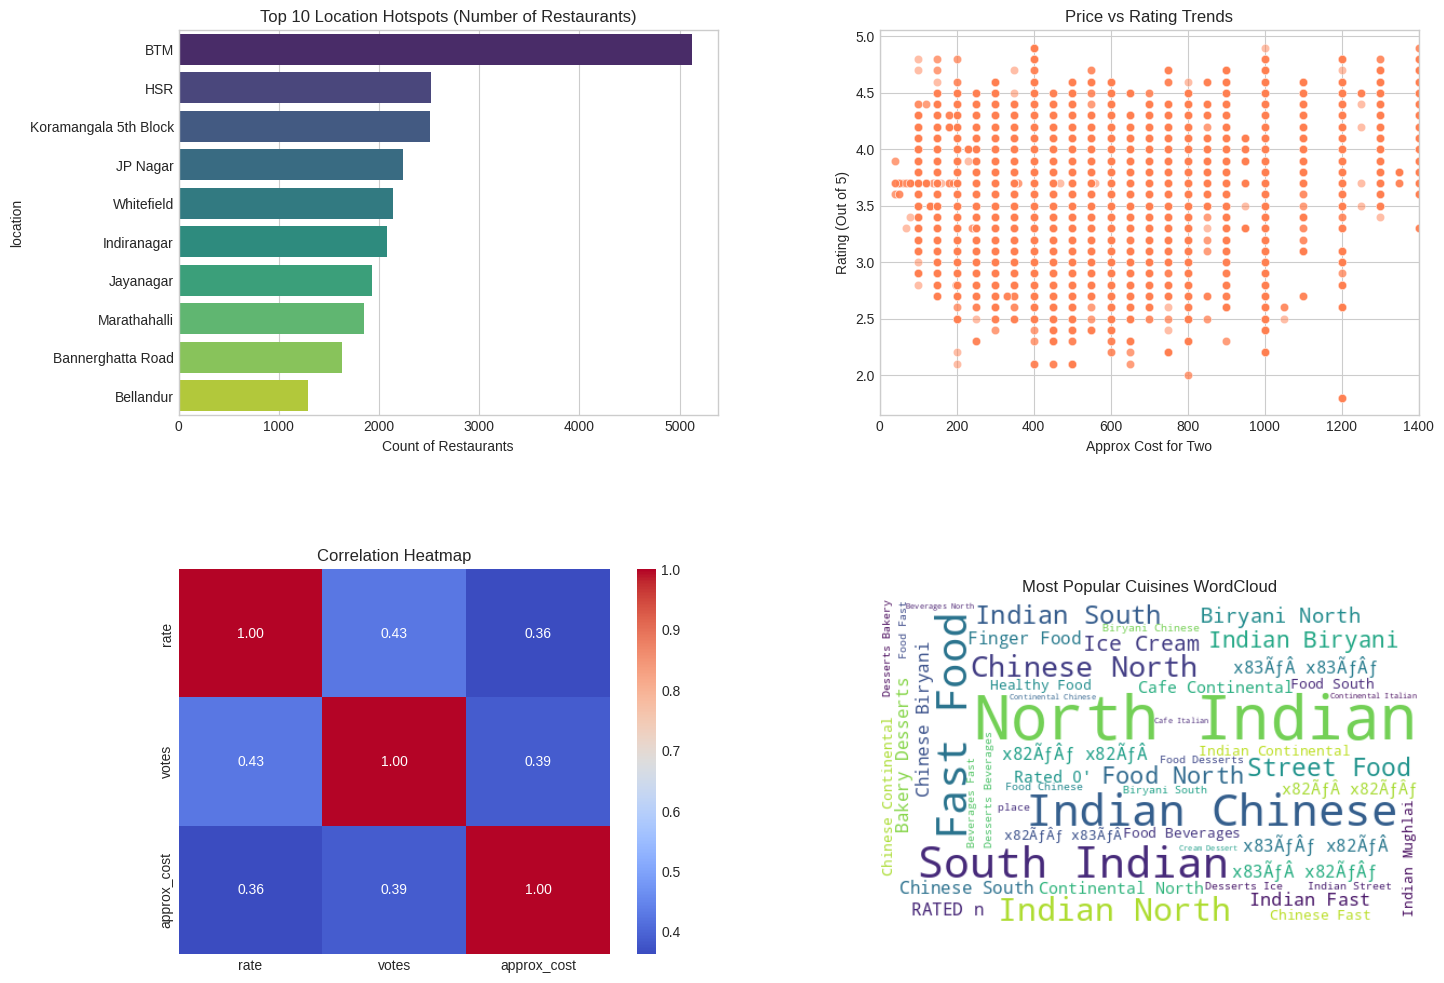

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)


top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Top 10 Location Hotspots (Number of Restaurants)')
axes[0, 0].set_xlabel('Count of Restaurants')

sns.scatterplot(data=df, x='approx_cost', y='rate', alpha=0.5, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Price vs Rating Trends')
axes[0, 1].set_xlabel('Approx Cost for Two')
axes[0, 1].set_ylabel('Rating (Out of 5)')
axes[0, 1].set_xlim(0, df['approx_cost'].quantile(0.95)) # Caps extreme outliers for a better view


corr_matrix = df[['rate', 'votes', 'approx_cost']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title('Correlation Heatmap')


cuisine_text = " ".join(c for c in df['cuisines'].dropna())
wordcloud = WordCloud(width=500, height=300, background_color='white', max_words=50).generate(cuisine_text)

axes[1, 1].imshow(wordcloud, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('Most Popular Cuisines WordCloud')

plt.show()

In [ ]:

df['votes'] = pd.to_numeric(df['votes'], errors='coerce')
df['approx_cost'] = pd.to_numeric(df['approx_cost'], errors='coerce')


df['votes'] = df['votes'].fillna(df['votes'].median())
df['approx_cost'] = df['approx_cost'].fillna(df['approx_cost'].median())

print("Glitched text successfully removed from numeric columns!")

Glitched text successfully removed from numeric columns!
